![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

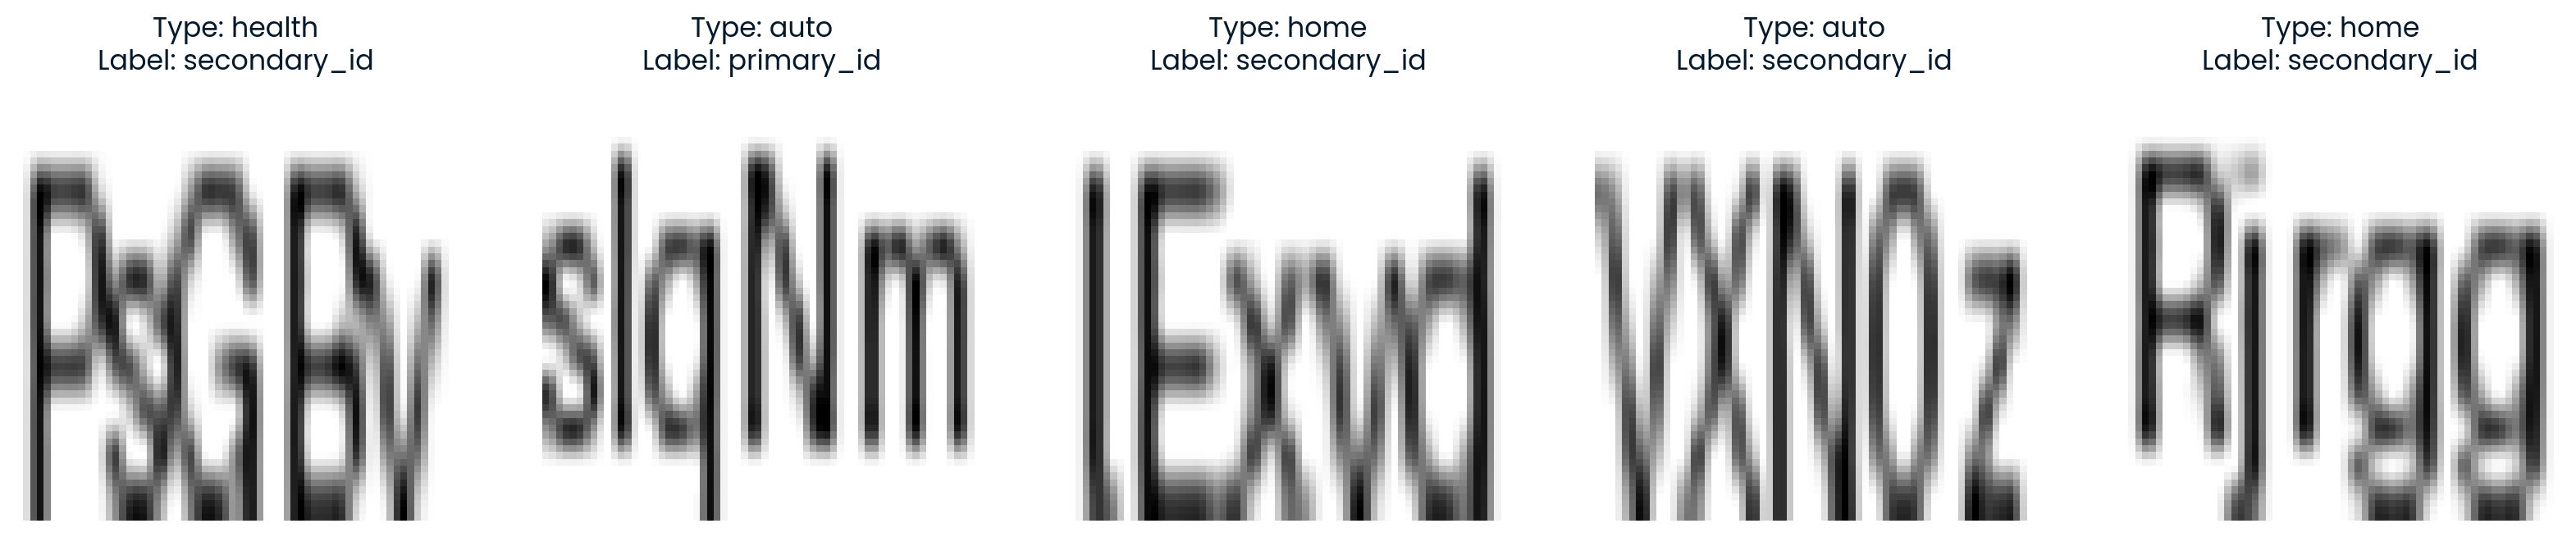

In [36]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

In [37]:
# Start coding here  

class OCRModel(nn.Module):
    def __init__(self, num_types=len(dataset.type_mapping), num_classes=len(dataset.label_mapping)):
        super(OCRModel, self).__init__()

        self.image_layer = nn.Sequential(
            nn.Conv2d(in_channels= 1, out_channels= 16, kernel_size= 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(in_channels= 16, out_channels= 64, kernel_size= 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Flatten() #out batch size should be 16384
        )

#type layer is much simpler
        self.type_layer = nn.Linear(num_types, 32)

        #create a final classifier
        self.fc = nn.Sequential(
            nn.Linear(16384 + 32, 256), #in channels are exactly image + type final size count
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    #define a forward pass
    def forward(self, image, type_in):
        img_features = self.image_layer(image)
        type_features = self.type_layer(type_in.float())
        full = torch.cat([img_features, type_features], dim = 1)
        return self.fc(full)
            

In [38]:
#make a data loader
loader = DataLoader(dataset, batch_size= 32, shuffle=True)

In [39]:
#instantiate criterion, loss, and optimizer
model = OCRModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [40]:
for epoch in range(10):
    total_loss = 0
    for img_batch, label_batch in loader:
        image      = img_batch[0]
        type_input = img_batch[1]

        optimizer.zero_grad()
        output = model(image, type_input)
        loss   = criterion(output, label_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/10 — Loss: {total_loss/len(loader):.4f}")

Epoch 1/10 — Loss: 0.8920
Epoch 2/10 — Loss: 0.6927
Epoch 3/10 — Loss: 0.6899
Epoch 4/10 — Loss: 0.6937
Epoch 5/10 — Loss: 0.6772
Epoch 6/10 — Loss: 0.6678
Epoch 7/10 — Loss: 0.6645
Epoch 8/10 — Loss: 0.6170
Epoch 9/10 — Loss: 0.5884
Epoch 10/10 — Loss: 0.4986
